
       SKIN ANALYSIS APPLICATION

----------------------------------------
Menu:
  1. Analisis Kulit (pilih gambar)
  2. Keluar


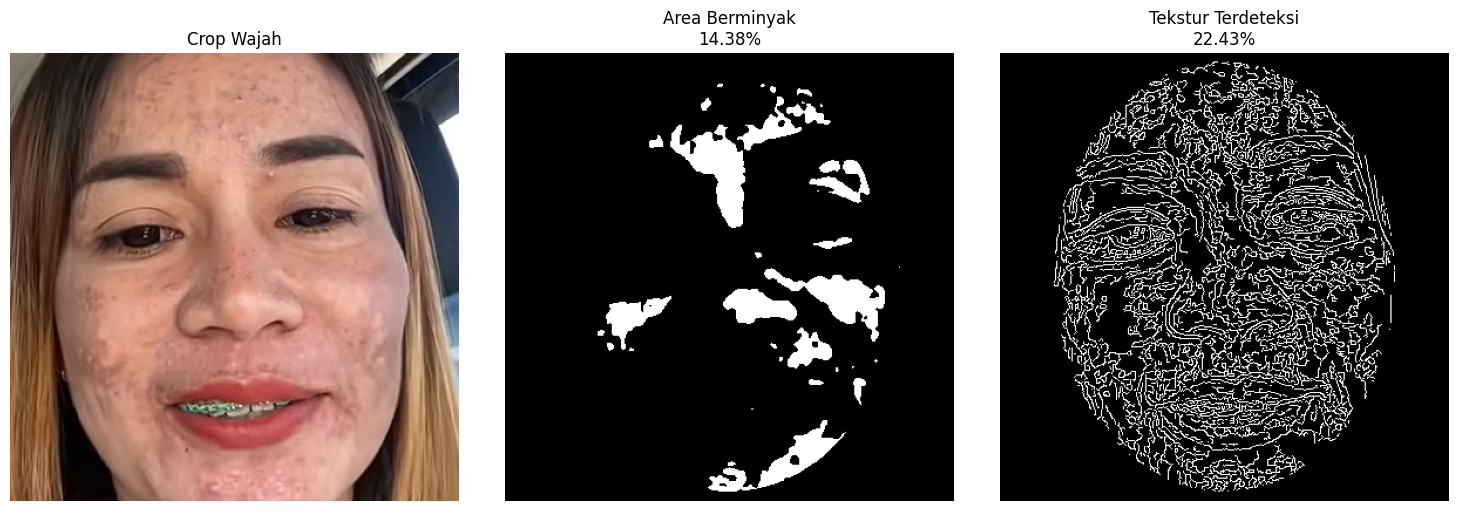


            HASIL ANALISIS KULIT
  * Kadar Minyak        : 14.38%
  * Tekstur Kulit       : 22.43%
  * Variasi Warna       : 8.48
--------------------------------------------------
  * SKOR KULIT AKHIR    : 84.28 / 100

INFO KONDISI KULIT:
- Kadar minyak rendah. Kulit cenderung normal atau kering.
- Tekstur kulit cukup halus, namun ada sedikit area dengan pori-pori terlihat.
- Warna kulit cukup merata, dengan sedikit perbedaan di beberapa area.


----------------------------------------
Menu:
  1. Analisis Kulit (pilih gambar)
  2. Keluar
Program selesai. Sampai jumpa!


In [5]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tkinter import Tk, filedialog

def pilih_gambar():
    """
    Menampilkan dialog file sistem untuk memilih gambar.
    Jika dibatalkan, fallback ke input path manual.
    """
    root = Tk()
    root.withdraw()
    root.attributes('-topmost', True)

    file_path = filedialog.askopenfilename(
        title="Pilih Gambar Wajah",
        filetypes=[("Image Files", "*.jpg *.jpeg *.png")]
    )
    root.destroy()

    if file_path:
        return file_path
    else:
        print("Tidak ada file dipilih melalui dialog.")
        path = input("Masukkan path gambar secara manual (kosongkan untuk batal): ").strip()
        return path if path else None


def analisis_kulit(image_path):
    """
    Membaca gambar, mendeteksi wajah, dan menghitung skor kulit.
    """
    if image_path is None:
        return False

    image = cv2.imread(image_path)
    if image is None:
        print("[ERROR] Gambar gagal dibaca. Pastikan path benar.")
        return False

    # Resize
    height, width = image.shape[:2]
    new_width = 500
    new_height = int((new_width / width) * height)
    image = cv2.resize(image, (new_width, new_height))

    # Deteksi wajah
    face_cascade = cv2.CascadeClassifier(
        cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
    )
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(
        gray, scaleFactor=1.1, minNeighbors=5, minSize=(100, 100)
    )

    if len(faces) == 0:
        print("[ERROR] Wajah tidak ditemukan pada gambar.")
        return False

    (x, y, w, h) = faces[0]
    face = image[y:y+h, x:x+w]
    face_gray = cv2.cvtColor(face, cv2.COLOR_BGR2GRAY)

    # Mask elips
    mask = np.zeros_like(face_gray)
    center = (w // 2, h // 2)
    axes = (int(w * 0.38), int(h * 0.48))
    cv2.ellipse(mask, center, axes, 0, 0, 360, 255, -1)

    # ---- Analisis Kadar Minyak ----
    blur = cv2.GaussianBlur(face_gray, (7, 7), 0)
    mean_brightness = np.mean(blur[mask > 0])
    threshold_value = mean_brightness + 30
    _, oily_mask = cv2.threshold(blur, threshold_value, 255, cv2.THRESH_BINARY)
    oily_mask = cv2.bitwise_and(oily_mask, mask)

    face_pixels = np.sum(mask == 255)
    oily_pixels = np.sum(oily_mask == 255)
    oily_percentage = (oily_pixels / face_pixels) * 100
    brightness_score = 100 - oily_percentage

    # ---- Analisis Tekstur ----
    edges = cv2.Canny(face_gray, 15, 45)
    edges = cv2.bitwise_and(edges, mask)
    texture_pixels = np.sum(edges == 255)
    texture_percentage = (texture_pixels / face_pixels) * 100
    texture_score = 100 - texture_percentage

    # ---- Analisis Variasi Warna ----
    face_rgb = cv2.cvtColor(face, cv2.COLOR_BGR2RGB)
    lab = cv2.cvtColor(face_rgb, cv2.COLOR_RGB2LAB)
    _, A, B = cv2.split(lab)
    color_variation = (np.std(A) + np.std(B)) / 2
    color_score = 100 - color_variation

    # Skor akhir
    skin_score = (brightness_score * 0.40) + (texture_score * 0.35) + (color_score * 0.25)

    # Visualisasi
    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    ax[0].imshow(cv2.cvtColor(face, cv2.COLOR_BGR2RGB))
    ax[0].set_title("Crop Wajah")
    ax[0].axis("off")

    ax[1].imshow(oily_mask, cmap='gray')
    ax[1].set_title(f"Area Berminyak\n{oily_percentage:.2f}%")
    ax[1].axis("off")

    ax[2].imshow(edges, cmap='gray')
    ax[2].set_title(f"Tekstur Terdeteksi\n{texture_percentage:.2f}%")
    ax[2].axis("off")

    plt.tight_layout()
    plt.show()

    # Hasil numerik
    print("\n" + "="*50)
    print("            HASIL ANALISIS KULIT")
    print("="*50)
    print(f"  * Kadar Minyak        : {oily_percentage:.2f}%")
    print(f"  * Tekstur Kulit       : {texture_percentage:.2f}%")
    print(f"  * Variasi Warna       : {color_variation:.2f}")
    print("-"*50)
    print(f"  * SKOR KULIT AKHIR    : {skin_score:.2f} / 100")
    print("="*50)

    # --- Kesimpulan Kondisi Kulit (deskriptif) ---
    print("\nINFO KONDISI KULIT:")
    # Minyak
    if oily_percentage > 40:
        print("- Kadar minyak tinggi. Area T-zone (dahi, hidung, dagu) cenderung lebih berminyak.")
    elif oily_percentage > 20:
        print("- Kadar minyak sedang. Beberapa bagian wajah tampak sedikit berminyak.")
    else:
        print("- Kadar minyak rendah. Kulit cenderung normal atau kering.")

    # Tekstur
    if texture_percentage > 25:
        print("- Tekstur kulit tampak kasar. Pori-pori atau garis halus cukup terlihat.")
    elif texture_percentage > 10:
        print("- Tekstur kulit cukup halus, namun ada sedikit area dengan pori-pori terlihat.")
    else:
        print("- Tekstur kulit halus, pori-pori tidak terlalu tampak.")

    # Warna
    if color_variation > 15:
        print("- Variasi warna cukup tinggi. Terdapat noda atau warna kulit tidak merata.")
    elif color_variation > 8:
        print("- Warna kulit cukup merata, dengan sedikit perbedaan di beberapa area.")
    else:
        print("- Warna kulit sangat merata, tidak tampak noda signifikan.")

    print("="*50 + "\n")
    return True


def main():
    print("\n" + "="*50)
    print("       SKIN ANALYSIS APPLICATION")
    print("="*50)
    while True:
        print("\n" + "-"*40)
        print("Menu:")
        print("  1. Analisis Kulit (pilih gambar)")
        print("  2. Keluar")
        pilihan = input("Masukkan pilihan (1/2): ").strip()

        if pilihan == "1":
            path = pilih_gambar()
            if path is None:
                print("Tidak ada gambar dipilih. Kembali ke menu.")
                continue
            analisis_kulit(path)
        elif pilihan == "2":
            print("Program selesai. Sampai jumpa!")
            break
        else:
            print("Pilihan tidak valid. Silakan coba lagi.")


if __name__ == "__main__":
    main()